# Entrega obligatoria — Diseño de Experimentos 2026
## Velocidad de descarga de Internet en función de la distancia al nodo

Una empresa de telecomunicaciones sospecha que la distancia entre el domicilio del cliente
y el nodo de distribución afecta la velocidad efectiva de descarga. Se midieron **30 conexiones**
con características tecnológicas similares.

En este notebook van los puntos **a) b) c) d) y e)**.
Los puntos **f)** y **g)** están resueltos en `regression.py` y se ven en `sandbox.ipynb`.



In [12]:
from regression import RegresionVelocidadDistancia
from puntos_a_e import *

regresion = RegresionVelocidadDistancia("../telecomunicaciones.xlsx")
datos = regresion.run()

datos.head()

,distancia,velocidad,ajuste,residuo
0,0.5,105.9,104.661505,1.238495
1,1.0,98.8,101.814965,-3.014965
2,1.5,101.7,98.968424,2.731576
3,2.0,105.3,96.121884,9.178116
4,2.5,90.4,93.275343,-2.875343


La tabla tiene la `distancia`, la `velocidad` observada, el valor de `ajuste` que da la recta
y el `residuo`, que es la diferencia entre lo observado y lo ajustado.

Miramos las dos variables:

In [13]:
datos[['distancia', 'velocidad']].describe().round(2)

,distancia,velocidad
count,30.00,30.00
mean,7.75,63.39
std,4.40,25.75
min,0.50,25.00
25%,4.12,43.75
50%,7.75,59.95
75%,11.38,86.55
max,15.00,105.90


Las distancias van de 0,5 a 15 km y las velocidades de 25 a 105,9 Mbps.
No hay datos faltantes.

<!--  -->
---

# a) ¿Hay relación entre las variables?

> *Mediante un gráfico examinen el comportamiento de la velocidad de descarga en función de la
> distancia al nodo. ¿El gráfico sugiere una relación entre las variables? Describan la dirección
> y el comportamiento de la relación.*

Lo primero es siempre el diagrama de dispersión, antes de ajustar nada:

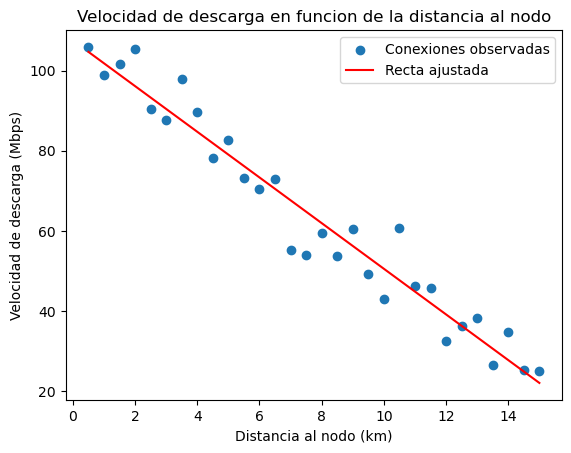

Pendiente: -5.6931  ->  la relacion es NEGATIVA (decreciente)


In [5]:
grafico_dispersion(regresion)

In [14]:
correlacion(regresion)

r de Pearson = -0.9731   (p-valor = 2.134e-19)
Asociacion lineal negativa y muy fuerte


(np.float64(-0.9731224418762491), np.float64(2.1336508049301025e-19))

### Respuesta

**El gráfico sugiere una relación bastante clara.**

**Dirección:** la relación es **negativa (decreciente)**. A medida que aumenta la distancia al nodo,
la velocidad de descarga baja. Las conexiones más cercanas, de 0,5 a 2 km, andan cerca de los
100 Mbps, y las más alejadas, de 13 a 15 km, no llegan a los 40.

**Comportamiento:** los puntos se alinean alrededor de una recta. No se ve curvatura —la caída no
se acelera ni se frena hacia los extremos— ni tampoco que la nube se abra o se cierre a medida que
avanza la distancia. 

El coeficiente de correlación de Pearson confirma lo que se ve: **r = −0,9731**, o sea una
asociación lineal negativa muy fuerte.

---

# b) El modelo propuesto

> *Propongan un modelo de regresión lineal que represente la relación entre la velocidad de descarga
> y la distancia al nodo. Identifiquen la variable dependiente y la variable independiente e
> interpreten cada término del modelo. ¿Qué supuestos deben cumplirse?*

In [16]:
mostrar_modelo()

Modelo de regresion lineal simple:

    y_i = B0 + B1 * x_i + e_i

    y_i = velocidad de descarga de la conexion i (Mbps)  -> DEPENDIENTE
    x_i = distancia al nodo de la conexion i (km)        -> INDEPENDIENTE
    B0  = velocidad media esperada a 0 km del nodo
    B1  = cuantos Mbps cambia la velocidad por cada km mas de distancia
    e_i = error aleatorio (todo lo que influye y no es la distancia)

Supuestos: linealidad, normalidad, homocedasticidad e independencia
           de los errores. Se verifican en el punto g).


### Respuesta

La **variable dependiente** es la velocidad de descarga y la **independiente** es la distancia al nodo.
Acá no hay mucho que discutir sobre cuál va en cada lugar: la distancia puede afectar la velocidad,
pero la velocidad no puede cambiar dónde vive el cliente.

Interpretando cada término en el contexto del problema:

| Término | Qué significa acá |
|---|---|
| $y_i$ | velocidad de descarga medida en la conexión $i$ |
| $\beta_0$ | velocidad media esperada a 0 km, o sea en el nodo mismo |
| $\beta_1$ | **cuántos Mbps cambia la velocidad por cada km más de distancia** |
| $x_i$ | distancia al nodo de la conexión $i$ |
| $\varepsilon_i$ | error aleatorio: todo lo que hace variar la velocidad y no es la distancia (calidad del cableado, congestión del nodo, equipamiento del cliente, plan contratado) |

**Los supuestos** salen del término de error. Como $\varepsilon$ recoge el efecto de todas las
variables que no metimos en el modelo, se supone que tiene distribución normal, media cero y
varianza constante; y además se pide que los errores sean independientes entre sí:

- **Linealidad:** la media de Y es una función lineal de X.
- **Normalidad:** $\varepsilon_i \sim N(0, \sigma^2)$.
- **Homocedasticidad:** la varianza del error es la misma para todo X.
- **Independencia:** el error de una observación no tiene nada que ver con el de otra.

Los cuatro se verifican en el punto g).

---

# c) Estimación de los parámetros

> *Estimen los parámetros del modelo propuesto. Escriban la estimación de la función de regresión
> e interpreten el significado de la pendiente en el contexto del problema.*

In [17]:
modelo = coeficientes(regresion)

Coeficientes de regresion

               Est.       E.E.      LI(95%)    LS(95%)       T     p-valor
const       107.5080     2.2600   102.8786   112.1375    47.57   2.496e-28
distancia    -5.6931     0.2546    -6.2146    -5.1715   -22.36   2.134e-19

Ecuacion estimada:
    velocidad = 107.5080 + (-5.6931) * distancia

s = raiz(CME) = 6.0352 Mbps

Interpretacion de la pendiente:
    por cada km mas de distancia al nodo, la velocidad baja
    en promedio 5.69 Mbps.


### Respuesta

La función de regresión estimada es:

$$\widehat{velocidad} = 107{,}5080 - 5{,}6931 \times distancia$$

**Interpretación de la pendiente:** por cada kilómetro adicional de distancia entre el domicilio y
el nodo, la velocidad de descarga baja en promedio **5,69 Mbps**. El signo negativo es el que
esperábamos y coincide con lo que muestra el gráfico.

Puesto en términos más útiles para la empresa: un cliente que vive **5 km más lejos** que otro tiene,
en promedio, unos **28,5 Mbps menos**. Sobre una velocidad media de 63,4 Mbps es una diferencia
importante.


---

# d) Velocidad estimada a 8 km

> *¿Cuál es la velocidad de descarga estimada para una conexión cuya distancia al nodo es de 8 km?*

In [19]:
estimar(regresion, 8)

Velocidad estimada a 8 km:  61.96 Mbps

    IC 95% para la media     : [59.70 ; 64.22]
    IC 95% para una conexion : [49.40 ; 74.53]

    8 km esta dentro del rango observado (0.5 a 15 km), asi que la
    estimacion es valida.


np.float64(61.963396366332965)

### Respuesta

Reemplazando en la ecuación: $107{,}5080 - 5{,}6931 \times 8 = \mathbf{61{,}96}$ **Mbps**.

La estimación es válida porque 8 km está dentro del rango observado, así que no estamos extrapolando.

**Un control que da bien:** en la muestra hay una conexión ubicada exactamente a 8 km, que midió
59,5 Mbps. El modelo predice 61,96, o sea que le erramos por 2,5 Mbps, bastante menos que el desvío
residual de 6,04. La recta ajusta bien en esa zona.

**Sobre los dos intervalos**, que dicen cosas distintas:

- El de la **media**, [59,70 ; 64,22], dice entre qué valores está el promedio de *todas* las
  conexiones ubicadas a 8 km.
- El de una **conexión individual**, [49,40 ; 74,53], es mucho más ancho porque además de la
  incertidumbre sobre dónde está la recta incorpora la variabilidad de cada caso.

Para la empresa esto significa dos cosas distintas: puede afirmar con confianza que sus clientes a
8 km promedian entre 60 y 64 Mbps, pero si un cliente puntual a esa distancia reclama porque le mide
51 Mbps, ese valor está dentro de lo esperable y no prueba por sí solo que haya una falla.

---

# e) Porcentaje de variación explicada

> *¿Qué porcentaje de la variación observada en la velocidad de descarga puede ser explicado por la
> distancia al nodo?*

In [21]:
r_cuadrado(regresion)

Descomposicion de la variabilidad

    SCT (total)      =   19230.89
    SCR (explicada)  =   18211.03   -> 94.7 %
    SCE (residual)   =    1019.87   -> 5.3 %

R2 = SCR/SCT = 0.9470

La distancia al nodo explica el 94.7 % de la variacion de la velocidad.
El 5.3 % restante son otras cosas que el modelo no incluye.


0.9469672868831928

### Respuesta

**La distancia al nodo explica el 94,7 % de la variación de la velocidad de descarga.**

La variación total se descompone en dos partes:

| Fuente | Suma de cuadrados | Porcentaje |
|---|---|---|
| Explicada por la distancia (SCR) | 18.211,03 | 94,7 % |
| No explicada (SCE) | 1.019,87 | 5,3 % |
| **Total (SCT)** | **19.230,89** | **100 %** |

El **5,3 % restante** queda dentro del término de error: son las diferencias entre conexiones que la
distancia no capta, como la calidad del cableado de cada domicilio, la congestión del nodo en el
momento de medir, el equipamiento del cliente o el plan contratado, más el error propio de la medición.

Un R² de 0,95 es alto. Igual conviene traducirlo a la escala del problema, que dice más que el
porcentaje solo: el **desvío residual es de 6,04 Mbps**, así que una estimación individual tiene un
error típico de unos 6 Mbps.

---

## Hasta acá los puntos a) a e)

```